# Practical Session 04b &mdash; Training logistic regression from scratch

**Companion to Lecture&nbsp;04.** The second of four notebooks. In 04a we built the model
$p=\sigma(\mathbf{w}^\top\mathbf{x}+b)$ and read its coefficients off scikit-learn. Now we
**train** it ourselves: the right loss (**cross-entropy**), its **gradient**, and **gradient
descent** &mdash; then check that we recover scikit-learn's coefficients and the data's true ones.

| # | Notebook | Topic |
|---|----------|-------|
| 04a | the model | the sigmoid, odds/log-odds, the decision boundary |
| **04b** | **training from scratch** | **cross-entropy, the gradient, gradient descent, convexity, $L_2$ (this notebook)** |
| 04c | evaluation | confusion matrix, precision/recall/F1, ROC/AUC, thresholds, imbalance |
| 04d | multiclass | softmax from scratch, cross-entropy, decision regions, digits |

> ⭐ **Key idea.** Fitting logistic regression = **maximum likelihood** = minimizing the
> **cross-entropy** loss $J(\mathbf{w},b)=-\tfrac1n\sum_i[y_i\log p_i+(1-y_i)\log(1-p_i)]$. Its
> gradient is astonishingly clean, $\nabla_{\mathbf{w}}J=\tfrac1n\mathbf{X}^\top(\mathbf{p}-\mathbf{y})$,
> and because $J$ is **convex**, gradient descent finds the one global minimum.

*Run each cell (Shift+Enter). Self-contained and offline.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from nb_utils import use_style
from nb_data import make_logistic_1d, make_logistic_2d

use_style("notes")

def sigmoid(z):
    "Numerically stable logistic sigmoid."
    z = np.asarray(z, float); out = np.empty_like(z)
    pos, neg = z >= 0, z < 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[neg]); out[neg] = ez / (1.0 + ez)
    return out

print("ready")

ready


## 1. Why not squared error?

Squared error worked for regression. For classification it has a fatal flaw: when the model is
**confidently wrong**, its gradient **vanishes**, so gradient descent stalls exactly where it
should push hardest. Compare, for a point whose true label is $y=1$, the per-example loss and the
size of its gradient w.r.t. the score $z$, as the predicted $p=\sigma(z)$ ranges over $(0,1)$:

* squared error $(p-1)^2$, gradient $\tfrac{d}{dz}=2(p-1)\,p(1-p)$;
* cross-entropy $-\log p$, gradient $\tfrac{d}{dz}=p-1$.

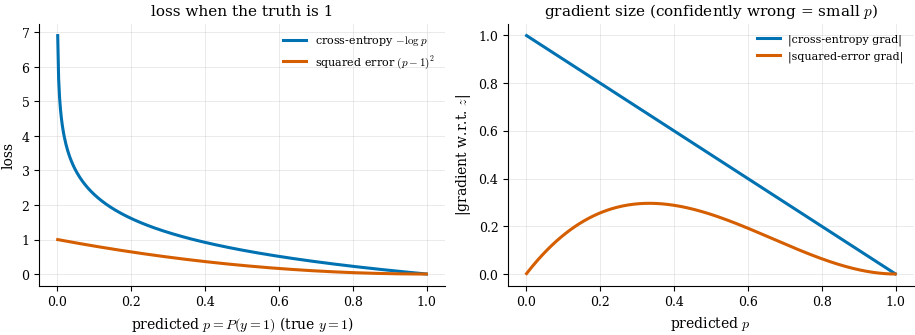

at p=0.02 (confidently wrong):  |MSE grad| = 0.0384  vs  |CE grad| = 0.98


In [2]:
p = np.linspace(1e-3, 1 - 1e-3, 400)     # predicted P(y=1); true label is y=1
mse_loss, ce_loss = (p - 1)**2, -np.log(p)
mse_grad, ce_grad = 2*(p - 1)*p*(1 - p), (p - 1)      # d/dz for each loss

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.2, 3.4))
a1.plot(p, ce_loss, color="#0072B2", lw=2.2, label="cross-entropy $-\\log p$")
a1.plot(p, mse_loss, color="#D55E00", lw=2.2, label="squared error $(p-1)^2$")
a1.set_xlabel("predicted $p=P(y{=}1)$ (true $y=1$)"); a1.set_ylabel("loss")
a1.set_title("loss when the truth is 1"); a1.legend(fontsize=8)
a2.plot(p, np.abs(ce_grad), color="#0072B2", lw=2.2, label="|cross-entropy grad|")
a2.plot(p, np.abs(mse_grad), color="#D55E00", lw=2.2, label="|squared-error grad|")
a2.set_xlabel("predicted $p$"); a2.set_ylabel("|gradient w.r.t. $z$|")
a2.set_title("gradient size (confidently wrong = small $p$)"); a2.legend(fontsize=8)
plt.show()
print("at p=0.02 (confidently wrong):  |MSE grad| =", round(abs(2*(0.02-1)*0.02*0.98), 4),
      " vs  |CE grad| =", round(abs(0.02-1), 4))

> ⚠️ **Watch out.** On the left, both losses fall as $p\to1$; but on the right, the squared-error
> gradient **collapses toward 0** for small $p$ (the point is very wrong, yet the update is tiny),
> while cross-entropy's gradient stays near $1$ and keeps pushing. Squared error on a sigmoid is
> also **non-convex**. Cross-entropy fixes both problems &mdash; and it is exactly the negative
> log-likelihood.

## 2. The cross-entropy loss (from scratch)

Assuming the labels are independent Bernoulli draws, maximizing the likelihood is the same as
minimizing the average **negative log-likelihood** &mdash; the cross-entropy:

$$J(\mathbf{w},b) = -\frac1n\sum_{i=1}^{n}\Bigl[\,y_i\log p_i+(1-y_i)\log(1-p_i)\,\Bigr],
\qquad p_i=\sigma(\mathbf{w}^\top\mathbf{x}_i+b).$$

We add a tiny $\varepsilon$ inside the logs for numerical safety.

In [3]:
X, y, w_true, b_true = make_logistic_2d(n=400, seed=0, w=(1.8, -2.2), b=0.5)

def cross_entropy(w, b, X, y, eps=1e-12):
    p = sigmoid(X @ w + b)
    return -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))

print("loss at w=0, b=0        :", round(cross_entropy(np.zeros(2), 0.0, X, y), 4),
      "  (= -log 0.5 =", round(-np.log(0.5), 4), ", the coin-flip baseline)")
print("loss at the TRUE (w, b) :", round(cross_entropy(w_true, b_true, X, y), 4))

loss at w=0, b=0        : 0.6931   (= -log 0.5 = 0.6931 , the coin-flip baseline)
loss at the TRUE (w, b) : 0.2657


## 3. The gradient, and a numerical check

The derivative of the cross-entropy is remarkably simple &mdash; the sigmoid's ugly factors cancel:

$$\frac{\partial J}{\partial \mathbf{w}}=\frac1n\sum_i(p_i-y_i)\,\mathbf{x}_i
=\frac1n\mathbf{X}^\top(\mathbf{p}-\mathbf{y}),\qquad
\frac{\partial J}{\partial b}=\frac1n\sum_i(p_i-y_i).$$

The "error" $p_i-y_i$ is the only thing that appears &mdash; the same clean form as linear regression.
We implement it and verify against a **finite-difference** gradient.

In [4]:
def loss_and_grad(w, b, X, y):
    n = len(y)
    p = sigmoid(X @ w + b)
    err = p - y                              # the (p - y) "error" signal
    grad_w = X.T @ err / n
    grad_b = err.mean()
    loss = cross_entropy(w, b, X, y)
    return loss, grad_w, grad_b

# numerical gradient by central differences
w0, b0 = np.array([0.3, -0.7]), 0.2
_, gw, gb = loss_and_grad(w0, b0, X, y)

h = 1e-6
gw_num = np.array([(cross_entropy(w0 + h*e, b0, X, y) - cross_entropy(w0 - h*e, b0, X, y)) / (2*h)
                   for e in np.eye(2)])
gb_num = (cross_entropy(w0, b0 + h, X, y) - cross_entropy(w0, b0 - h, X, y)) / (2*h)

print("analytic grad_w:", gw.round(6), " numeric:", gw_num.round(6))
print("analytic grad_b:", round(gb, 6), " numeric:", round(gb_num, 6))
print("match:", np.allclose(gw, gw_num, atol=1e-5) and np.isclose(gb, gb_num, atol=1e-5))

analytic grad_w: [-0.235657  0.098384]  numeric: [-0.235657  0.098384]
analytic grad_b: -0.04255  numeric: -0.04255
match: True


## 4. Gradient descent (a from-scratch estimator)

Now walk downhill: repeatedly step the parameters against the gradient,
$\mathbf{w}\leftarrow\mathbf{w}-\eta\,\nabla_{\mathbf{w}}J$. We wrap it in a small estimator, fit
our synthetic data, watch the loss fall, and compare the learned coefficients to **scikit-learn**
(with almost no regularization) and to the **true** generating $(\mathbf{w},b)$.

In [ ]:
class LogisticRegressionGD:
    def __init__(self, lr=0.5, n_iter=2000):
        self.lr, self.n_iter = lr, n_iter
    def fit(self, X, y):
        n, d = X.shape
        self.w, self.b = np.zeros(d), 0.0
        self.loss_ = []
        for _ in range(self.n_iter):
            loss, gw, gb = loss_and_grad(self.w, self.b, X, y)
            self.w -= self.lr * gw
            self.b -= self.lr * gb
            self.loss_.append(loss)
        return self
    def predict_proba(self, X): return sigmoid(X @ self.w + self.b)
    def predict(self, X):       return (self.predict_proba(X) >= 0.5).astype(int)

gd = LogisticRegressionGD(lr=0.5, n_iter=3000).fit(X, y)

from sklearn.linear_model import LogisticRegression
sk = LogisticRegression(C=1e6).fit(X, y)     # C=1e6 -> essentially unregularized MLE

print(f"true      w = {w_true},           b = {b_true:.3f}")
print(f"our GD    w = {gd.w.round(3)}, b = {gd.b:.3f}")
print(f"sklearn   w = {sk.coef_[0].round(3)}, b = {sk.intercept_[0]:.3f}")
print("our GD matches sklearn:", np.allclose(gd.w, sk.coef_[0], atol=1e-2) and
      np.isclose(gd.b, sk.intercept_[0], atol=1e-2))

fig, ax = plt.subplots(figsize=(6.0, 3.4))
ax.plot(gd.loss_, color="#0072B2")
ax.set_xlabel("iteration"); ax.set_ylabel("cross-entropy $J$")
ax.set_title("gradient descent drives the loss down"); plt.show()

## 5. The loss is convex &mdash; a single bowl

Unlike squared-error-on-a-sigmoid, the cross-entropy is **convex** in $(\mathbf{w},b)$: one global
minimum, no false bottoms. With one feature we can see the whole surface over the parameter plane
$(w,b)$ &mdash; a smooth bowl, and gradient descent just rolls to the bottom.

In [ ]:
x1, y1, _, _ = make_logistic_1d(n=120, seed=5, w=1.5, b=-0.5)
X1 = x1.reshape(-1, 1)

ws = np.linspace(-2, 6, 120); bs = np.linspace(-5, 4, 120)
WW, BB = np.meshgrid(ws, bs)
J = np.array([[cross_entropy(np.array([w]), b, X1, y1) for w in ws] for b in bs])

fig = plt.figure(figsize=(9.4, 3.7))
ax1 = fig.add_subplot(1, 2, 1)
cs = ax1.contourf(WW, BB, J, levels=25, cmap="viridis")
imin = np.unravel_index(J.argmin(), J.shape)
ax1.plot(WW[imin], BB[imin], "r*", ms=14)
ax1.set_xlabel("$w$"); ax1.set_ylabel("$b$"); ax1.set_title("cross-entropy $J(w,b)$")
fig.colorbar(cs, ax=ax1, shrink=0.85)
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.plot_surface(WW, BB, J, cmap="viridis", alpha=0.9, linewidth=0)
ax2.set_xlabel("$w$"); ax2.set_ylabel("$b$"); ax2.set_zlabel("$J$"); ax2.set_title("the convex bowl")
plt.show()

> 🔬 **Going deeper (why convex).** The Hessian of $J$ is
> $\tfrac1n\sum_i p_i(1-p_i)\,\mathbf{x}_i\mathbf{x}_i^\top$, a sum of rank-1 terms with weights
> $p_i(1-p_i)>0$ &mdash; so it is **positive semidefinite** everywhere. That is the formal reason the
> surface is a bowl and gradient descent cannot get stuck.

## 6. $L_2$ regularization (weight decay)

On separable data the weights can run off to infinity (pushing every probability to 0 or 1). A
small $L_2$ penalty $\tfrac{\lambda}{2}\lVert\mathbf{w}\rVert^2$ keeps them finite; it adds
$\lambda\mathbf{w}$ to the gradient (the bias $b$ is not penalized). Larger $\lambda$ = stronger
shrinkage. scikit-learn uses the inverse convention $C=1/\lambda$ &mdash; *small* $C$ = *strong*
regularization.

In [ ]:
def fit_l2(X, y, lam, lr=0.3, n_iter=4000):
    n, d = X.shape; w, b = np.zeros(d), 0.0
    for _ in range(n_iter):
        p = sigmoid(X @ w + b); err = p - y
        w -= lr * (X.T @ err / n + lam * w)     # penalty adds lam*w to grad_w
        b -= lr * err.mean()                    # b is NOT penalized
    return w, b

for lam in [0.0, 0.1, 1.0, 5.0]:
    w, b = fit_l2(X, y, lam)
    print(f"lambda={lam:4.1f} -> ||w|| = {np.linalg.norm(w):.3f}   w = {w.round(3)}")

# the shrinkage matches sklearn's C = 1/(n*lambda) convention (penalty on the summed loss)
n = len(y)
w_ours, b_ours = fit_l2(X, y, lam=1.0)
sk_reg = LogisticRegression(C=1.0 / (n * 1.0)).fit(X, y)
print("\\nour lambda=1 vs sklearn C=1/(n*lambda):")
print("  ours   :", w_ours.round(3), round(b_ours, 3))
print("  sklearn:", sk_reg.coef_[0].round(3), round(sk_reg.intercept_[0], 3))

> 💡 **Intuition.** Regularization trades a little training fit for smaller, steadier weights that
> generalize better &mdash; the same bias&ndash;variance lever as ridge in Session&nbsp;03, now on a
> classifier. Choosing $\lambda$ (equivalently $C$) is a model-selection job for cross-validation.

## Recap & exercises

**Recap.**
* **Squared error** on a sigmoid stalls when confidently wrong (vanishing gradient) and is non-convex; **cross-entropy** fixes both.
* Cross-entropy is the **negative log-likelihood**: $J=-\tfrac1n\sum_i[y_i\log p_i+(1-y_i)\log(1-p_i)]$.
* Its gradient is clean: $\nabla_{\mathbf{w}}J=\tfrac1n\mathbf{X}^\top(\mathbf{p}-\mathbf{y})$,
  $\partial_b J=\overline{p-y}$ &mdash; verified against finite differences.
* **Gradient descent** recovers scikit-learn's coefficients and (with enough data) the true ones; $J$ is **convex** (PSD Hessian), so there is one global minimum.
* **$L_2$** ($\lambda$, or $C=1/\lambda$) shrinks the weights and keeps them finite on separable data.

**Exercises.**
1. Set the learning rate to `lr=5.0` and to `lr=0.02`. Which diverges, which crawls? Plot both loss curves.
2. Implement **mini-batch** GD (update on random subsets of rows). Does the loss curve get noisier? Does it still converge?
3. Replace the `(p-y)` gradient with the **squared-error** gradient `2*(p-y)*p*(1-p)` and refit. Does it reach the same solution as fast? (This is Section&nbsp;1 in action.)
4. Add an intercept column of ones to `X` and fold `b` into `w`. Verify you get the same fit with a single weight vector.
5. Sweep $\lambda$ over `np.logspace(-3, 2, 20)` and plot $\lVert\mathbf{w}\rVert$ vs $\lambda$ &mdash; the shrinkage path.

*Next:* **04c &mdash; evaluating a classifier**: turning probabilities into decisions, the confusion
matrix, precision/recall/F1, ROC/AUC, and why accuracy lies under class imbalance.